# **MÓDULO 17 - Projeto de Credit Score - Parte 1 - Processamento dos dados**


Essa é a primeira etapa do processo de Credit Score que vocês desenvolverão durante nosso curso.
Nessa primeira etapa vocês irão aplicar os passos aprendidos nos módulos de pré processamento para preparar a base de vocês para o desenvolvimento do modelo.

O termo "credit score" se refere a uma pontuação numérica que representa a credibilidade de um indivíduo em termos de cumprimento de obrigações financeiras, como pagar contas de empréstimos, cartões de crédito, entre outros. Essa pontuação é calculada com base em diversas informações financeiras e de crédito do indivíduo, como histórico de pagamentos, níveis de endividamento, tempo de crédito, tipos de crédito utilizados, entre outros.

O objetivo de um modelo de credit score é prever o risco de um indivíduo se tornar inadimplente com suas obrigações financeiras. Em outras palavras, o modelo avalia a probabilidade de um indivíduo não cumprir com os pagamentos de empréstimos ou outros compromissos financeiros. Essa previsão é fundamental para instituições financeiras, como bancos e credores, na tomada de decisão sobre a concessão de crédito. Um modelo de credit score eficaz pode ajudar essas instituições a avaliar o risco de emprestar dinheiro a um determinado indivíduo e, assim, tomar decisões mais informadas sobre a aprovação ou negação de crédito, bem como sobre os termos e condições desses empréstimos.

**Atenção:** Notem que esse projeto é diferente da base que tenho trabalhado com vocês em aula, apesar de se tratar de uma base bancária durante a aula falamos sobre a variável Churn a ser prevista, nesse caso a previsão seria do valor do Score de Crédito.

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px

In [4]:
#Lembrem-se sempre de alterar a importação dos dados de acordo com o diretório de vocês.
df = pd.read_csv("CREDIT_SCORE_PROJETO_PARTE1.csv", delimiter=';')

df.head(10)

,Age,Gender,Income,Education,Marital Status,Number of Children,Home Ownership,Credit Score
0,25.0,Female,"50.000,00",Bachelor's Degree,Single,0,Rented,High
1,30.0,Male,"100.000,00",Master's Degree,Married,2,Owned,High
2,35.0,Female,"75.000,00",Doctorate,Married,1,Owned,High
3,40.0,Male,"125.000,00",High School Diploma,Single,0,Owned,High
4,45.0,Female,"100.000,00",Bachelor's Degree,Married,3,Owned,High
5,50.0,Male,"150.000,00",Master's Degree,Married,0,Owned,High
6,26.0,Female,"40.000,00",Associate's Degree,Single,0,Rented,Average
7,31.0,Male,"60.000,00",Bachelor's Degree,Single,0,Rented,Average
8,NaN,Female,"80.000,00",Master's Degree,Married,2,Owned,High
9,NaN,Male,"105.000,00",Doctorate,Single,0,Owned,High


Legenda dos dados:

*   **Age** : Idade dos nossos clientes.

*   **Income** : Salário Mensal.

*   **Gender** : Gênero.

*   **Education** : Nível de escolaridade dos clientes.

*   **Marital** : Status Civilmente.

*   **Number of Children** : Quantidade de filhos.

*   **Home** : Tipo de residência, alugada ou própria.

*   **Credit Score** : Nossa variável preditora, o score de crédito dos clientes.


# Etapa 1: Relize os passos que vimos no módulo 18, de pré processamento dos dados.

**A) Verifique os tipos de dados, fazendo as transformações quando necessário.**


In [7]:
#verificando informações básicas no df
df.info() 

<class 'pandas.DataFrame'>
RangeIndex: 164 entries, 0 to 163
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 130 non-null    float64
 1   Gender              164 non-null    str    
 2   Income              164 non-null    str    
 3   Education           164 non-null    str    
 4   Marital Status      164 non-null    str    
 5   Number of Children  164 non-null    int64  
 6   Home Ownership      164 non-null    str    
 7   Credit Score        164 non-null    str    
dtypes: float64(1), int64(1), str(6)
memory usage: 10.4 KB


In [ ]:
#As colunas Age (idade), Income(Renda) estão como float e str respectivamente. Será necessário analisar e transformar em int para manipulá-las depois.

In [9]:
#Verificando se na coluna 'Age' há decimais diferentes de ".0", para converter diretamente para int, sem risco de cortar outros valores
#pois ela se apresenta como float.
df[df['Age'] % 1 != 0] 

,Age,Gender,Income,Education,Marital Status,Number of Children,Home Ownership,Credit Score
8,NaN,Female,"80.000,00",Master's Degree,Married,2,Owned,High
9,NaN,Male,"105.000,00",Doctorate,Single,0,Owned,High
10,NaN,Female,"90.000,00",High School Diploma,Married,1,Owned,High
11,NaN,Male,"135.000,00",Bachelor's Degree,Married,0,Owned,High
12,NaN,Female,"35.000,00",High School Diploma,Single,0,Rented,Low
13,NaN,Male,"55.000,00",Associate's Degree,Single,0,Rented,Average
14,NaN,Female,"70.000,00",Bachelor's Degree,Married,2,Owned,High
15,NaN,Male,"95.000,00",Master's Degree,Single,0,Owned,High
16,NaN,Female,"85.000,00",Doctorate,Married,1,Owned,High
17,NaN,Male,"125.000,00",High School Diploma,Married,0,Owned,High


In [ ]:
#Colunas vazias, indicativo de decimais apenas em ".0"

In [10]:
#Conversão da coluna 'Age' em int.
df['Age'] = df['Age'].astype(int)

In [5]:
#removendo pontuações de str, e convertendo Income(renda) para float.
df['Income'] = (
    df['Income']
        .str.replace('.', '', regex=False)
        .str.replace(',', '.', regex=False)
)

In [6]:
df['Income'] = df['Income'].astype(float)

In [7]:
df.info() 

<class 'pandas.DataFrame'>
RangeIndex: 164 entries, 0 to 163
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 130 non-null    float64
 1   Gender              164 non-null    str    
 2   Income              164 non-null    float64
 3   Education           164 non-null    str    
 4   Marital Status      164 non-null    str    
 5   Number of Children  164 non-null    int64  
 6   Home Ownership      164 non-null    str    
 7   Credit Score        164 non-null    str    
dtypes: float64(2), int64(1), str(5)
memory usage: 10.4 KB


In [ ]:
#Colunas corrigidas e convertidas

**B) Verifique se temos colunas com dados faltantes.
Caso existam colunas com dados faltantes faça o tratamento desses dados, excluindo ou substituindo esses valores. Justifique sua escolha.**

In [8]:
#verificando se há presença de dados faltantes.
df.isnull().sum()
(df.isnull().sum() / len(df)) *100 #contando porcentagem de dados nulos

Age                   20.731707
Gender                 0.000000
Income                 0.000000
Education              0.000000
Marital Status         0.000000
Number of Children     0.000000
Home Ownership         0.000000
Credit Score           0.000000
dtype: float64

In [ ]:
#Muitos dados de 'Age' estão faltando, plotarei um gráfico para ver a distribuição e verificar melhor modo de tratar esses dados faltantes.

In [17]:
df['Age'].isnull().sum()

np.int64(34)

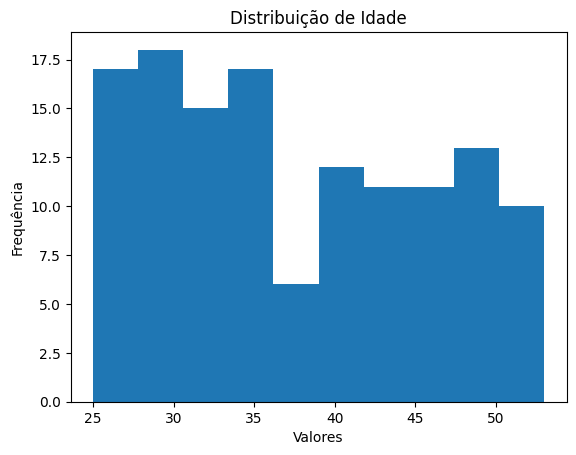

In [18]:
#Gráfico de distribuição da coluna 'Age'
df['Age'].plot(kind='hist', bins=10, title='Distribuição de Idade')
plt.xlabel('Valores')
plt.ylabel('Frequência')
plt.show()

In [ ]:
#Os dados de 'Age' são assimétricos (como esperado para idade), por serem assim vamos utilizar a Mediana para substituir esses dados.

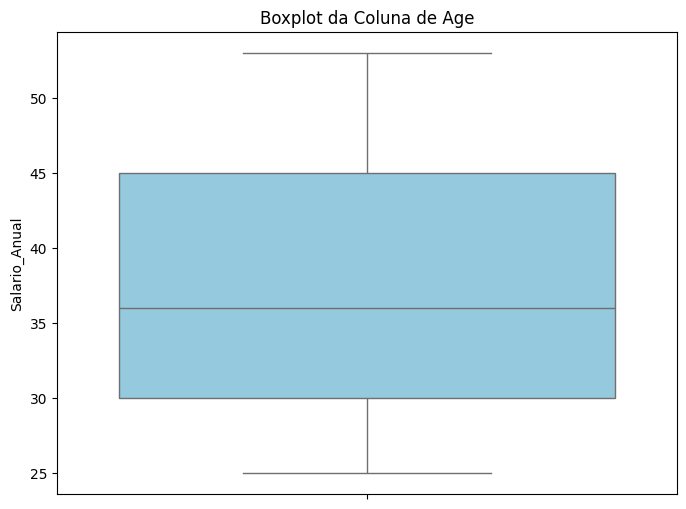

In [15]:
#boxplot verificando se há presença de Outliers, não houve
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, y='Age', color='skyblue')
plt.title('Boxplot da Coluna de Age')
plt.ylabel('Salario_Anual')
plt.show()

In [19]:
df['Age'].median() 

np.float64(36.0)

In [9]:
#Aplicando mediana nos valores faltantes
mediana = df['Age'].median() 
df['Age'] = df['Age'].fillna(mediana, inplace=True)

C:\Users\tmjbe\AppData\Local\Temp\ipykernel_26944\3592979822.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Age'] = df['Age'].fillna(mediana, inplace=True)


In [21]:
df['Age'].isnull().sum() #coluna 'Age' tratada.

np.int64(0)

In [19]:
#verificando se há presença de dados faltantes.
df.isnull().sum()
(df.isnull().sum() / len(df)) *100 

Age                   0.0
Gender                0.0
Income                0.0
Education             0.0
Marital Status        0.0
Number of Children    0.0
Home Ownership        0.0
Credit Score          0.0
dtype: float64

In [21]:
#Colunas tratadas

**C) Verifique se temos valores digitados de forma incorreta nas variáveis categóricas que necessitem de tratamento.**

In [20]:
#Código exibe todas os valores únicos de cada coluna categórica
colunas_categoricas = df.select_dtypes(include='object').columns
for col in colunas_categoricas:
    print("Coluna:", col)
    print(df[col].unique())  # valores únicos
    print("\n")

Coluna: Gender
<StringArray>
['Female', 'Male']
Length: 2, dtype: str


Coluna: Education
<StringArray>
[  'Bachelor's Degree',     'Master's Degree',           'Doctorate',
 'High School Diploma',  'Associate's Degree']
Length: 5, dtype: str


Coluna: Marital Status
<StringArray>
['Single', 'Married']
Length: 2, dtype: str


Coluna: Home Ownership
<StringArray>
['Rented', 'Owned']
Length: 2, dtype: str


Coluna: Credit Score
<StringArray>
['High', 'Average', 'Low']
Length: 3, dtype: str




C:\Users\tmjbe\AppData\Local\Temp\ipykernel_11980\3169547647.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  colunas_categoricas = df.select_dtypes(include='object').columns


In [ ]:
#Valores únicos normais, sem necessidade de alterar.

In [11]:
#Mudando o nome de algumas colunas para ficar mais dinâmico e organizado.
df = df.rename(columns={'Marital Status': 'Marital_Status', 'Number of Children': 'Number_Childreen',
                        'Home Ownership': 'Home_Ownership', 'Credit Score': 'Credit_Score'})
df.head()

,Age,Gender,Income,Education,Marital_Status,Number_Childreen,Home_Ownership,Credit_Score
0,25,Female,50000.0,Bachelor's Degree,Single,0,Rented,High
1,30,Male,100000.0,Master's Degree,Married,2,Owned,High
2,35,Female,75000.0,Doctorate,Married,1,Owned,High
3,40,Male,125000.0,High School Diploma,Single,0,Owned,High
4,45,Female,100000.0,Bachelor's Degree,Married,3,Owned,High


# Etapa 2: Relize os passos que vimos no módulo 15, de análise.

**A) Realiza a análise univariada, aplique a função describe ao nosso dataframe para verificar os dados das variáveis numéricas, se encontrar a possível presença de outliers analise com gráficos a distribuição dos dados.Traga insights sobre os dados analisados.**

In [24]:
df.describe()

,Age,Income,Number_Childreen
count,164.000000,164.000000,164.000000
mean,37.195122,83765.243902,0.652439
std,7.586619,32457.306728,0.883346
min,25.000000,25000.000000,0.000000
25%,31.750000,57500.000000,0.000000
50%,36.000000,83750.000000,0.000000
75%,43.000000,105000.000000,1.000000
max,53.000000,162500.000000,3.000000


In [ ]:
#Os valores das médias e medianas estão bem próximos, não aparentando presença de Outliers, irei plotar gráficos para certificar.

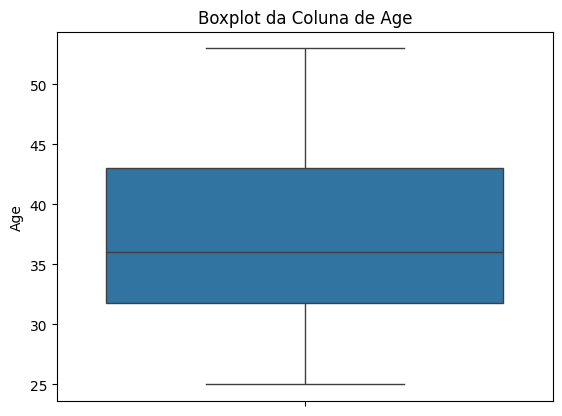

In [25]:
#Gráfico de análise univariada 
sns.boxplot(data=df, y='Age')
plt.title('Boxplot da Coluna de Age')
plt.show()

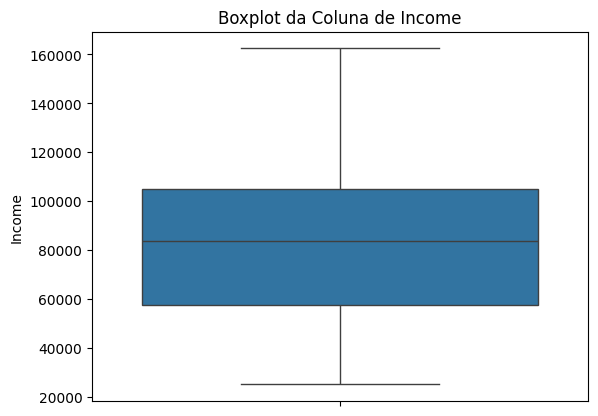

In [26]:
#Gráfico de análise univariada 
sns.boxplot(data=df, y='Income')
plt.title('Boxplot da Coluna de Income')
plt.show()

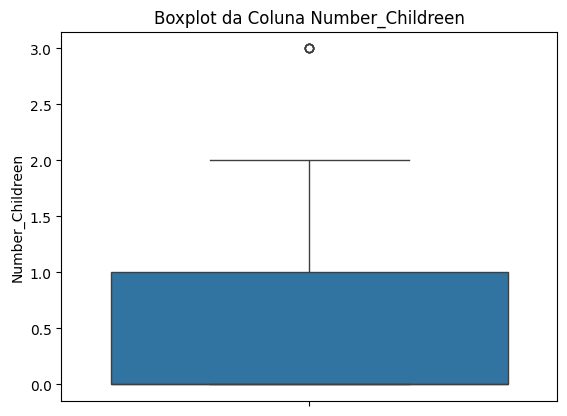

In [27]:
#Gráfico de análise univariada 
sns.boxplot(data=df, y='Number_Childreen')
plt.title('Boxplot da Coluna Number_Childreen')
plt.show()

In [ ]:
#Gráficos de 'Age' e 'Income' não possui presença de Outlier. Ambos aparentam uma distribuição equilibrada com concentração mais inferior do dados
#O gráfico da coluna 'Number_Childreen' aprensenta a presença de Outlier no gráfico, porém os valores que possuem nessa variável são apenas quatro valores.

In [32]:
df['Number_Childreen'].unique()

array([0, 2, 1, 3])

In [39]:
#O gráfico de boxplot apresenta esse valor como Outlier, porém só possuem quatro valores, não aparentando ser um Outlier real. Parece um dado real. 
#Isso pode acontecer pela distribuição dos dados, como observado abaixo as porcentagens.
df['Number_Childreen'].value_counts(normalize=True) * 100

Number_Childreen
0    59.146341
1    19.512195
2    18.292683
3     3.048780
Name: proportion, dtype: float64

In [35]:
df[df['Number_Childreen'] > 2]
#Pelo observado no gráfico, os dados parecem ser um comportamento normal da variável e não um Outlier.

,Age,Gender,Income,Education,Marital_Status,Number_Childreen,Home_Ownership,Credit_Score
4,45,Female,100000.0,Bachelor's Degree,Married,3,Owned,High
33,45,Female,105000.0,Bachelor's Degree,Married,3,Owned,High
65,45,Female,110000.0,Bachelor's Degree,Married,3,Owned,High
97,45,Female,115000.0,Bachelor's Degree,Married,3,Owned,High
139,45,Female,105000.0,Bachelor's Degree,Married,3,Owned,High


**B) Agora realize a análise univariada para as variaveis categóricas, plote gráficos para entender a distribuição das categorias e tente retirar insights de cada gráfico.**

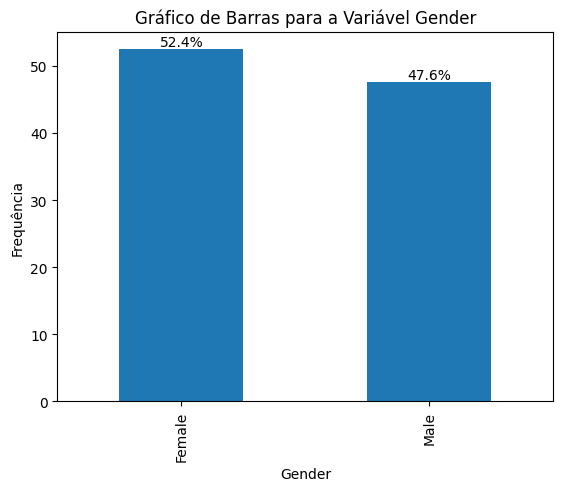

In [102]:
# Contagem dos valores da coluna de gender
contagem_gender = df['Gender'].value_counts()
porcentagem_gender = (contagem_gender / contagem_gender.sum()) * 100

#Análise univariada
ax = porcentagem_gender.plot(kind='bar')
plt.title('Gráfico de Barras para a Variável Gender')
plt.xlabel('Gender')
plt.ylabel('Frequência')

# Adiciona os rótulos em cima das barras
ax.bar_label(ax.containers[0], fmt='%.1f%%')
plt.show()


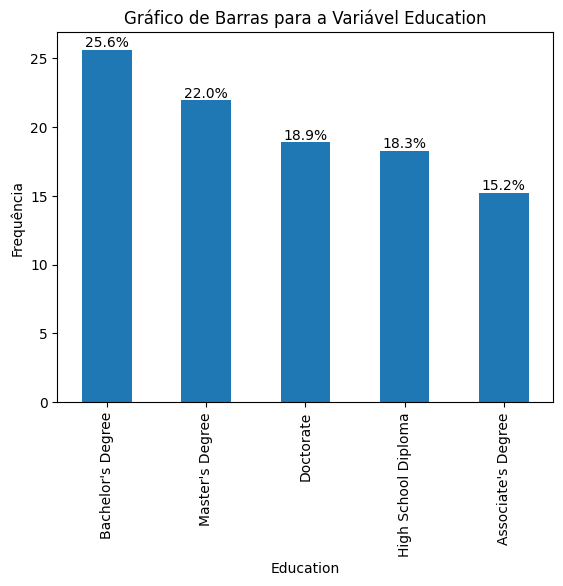

In [101]:
contagem_education = df['Education'].value_counts()
porcentagem_ed = (contagem_education / contagem_education.sum()) * 100

ax = porcentagem_ed.plot(kind='bar')
plt.title('Gráfico de Barras para a Variável Education')
plt.xlabel('Education')
plt.ylabel('Frequência')

ax.bar_label(ax.containers[0], fmt='%.1f%%')
plt.show()

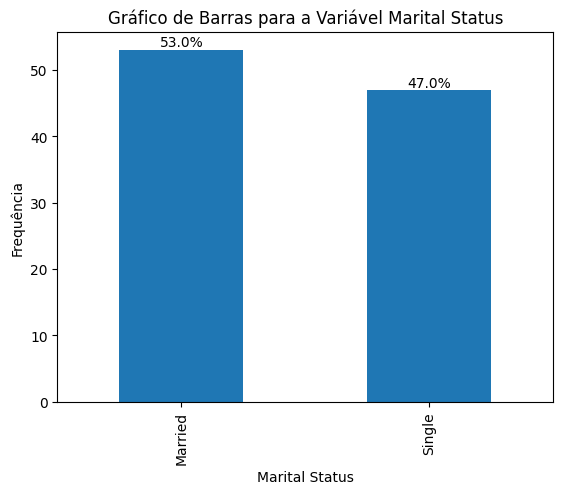

In [100]:
contagem_m_s = df['Marital_Status'].value_counts()
porcentagem_m_s = (contagem_m_s / contagem_m_s.sum()) * 100

ax = porcentagem_m_s.plot(kind='bar')
plt.title('Gráfico de Barras para a Variável Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Frequência')

ax.bar_label(ax.containers[0], fmt='%.1f%%')
plt.show()

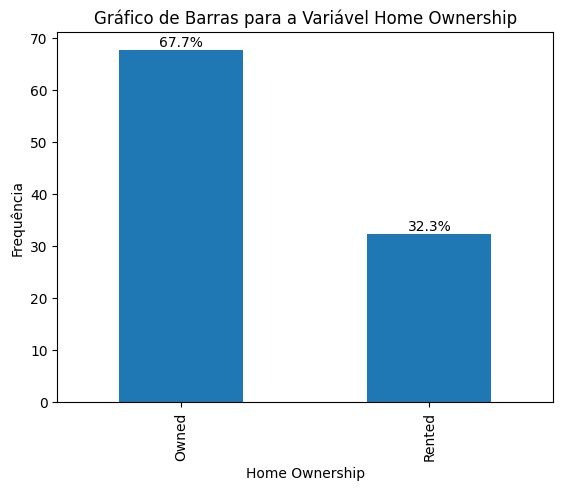

In [103]:
contagem_h_o = df['Home_Ownership'].value_counts()
porcentagem_h_o = (contagem_h_o / contagem_h_o.sum()) * 100

ax = porcentagem_h_o.plot(kind='bar')
plt.title('Gráfico de Barras para a Variável Home Ownership')
plt.xlabel('Home Ownership')
plt.ylabel('Frequência')

ax.bar_label(ax.containers[0], fmt='%.1f%%')
plt.show()

Text(0, 0.5, 'Frequência')

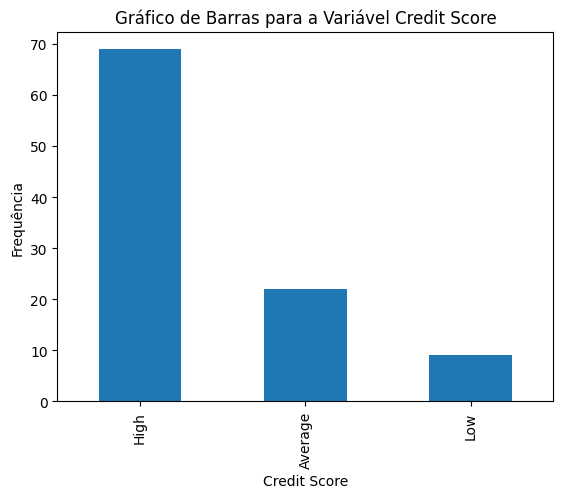

In [106]:
contagem_c_s = df['Credit_Score'].value_counts()
porcentagem_c_s = (contagem_c_s / contagem_c_s.sum()) * 100

ax = porcentagem_c_s.plot(kind='bar')
plt.title('Gráfico de Barras para a Variável Credit Score')
plt.xlabel('Credit Score')
plt.ylabel('Frequência')

ax.bar_label(ax.containers[0], fmt='%.1f%%')
plt.show()

**C) Você encontrou alguma coluna com outliers?
Se sim realize o tratamento desses casos.**

In [40]:
#Não foi encontrados Outliers reais nos gráficos. 

**D) Realize a análise Bivariada.
Tente responder as seguintes perguntas com gráficos seguidos de insights:**



*   Existe relação entre a idade e o status civil?
*   Qual a relação entre o score de crédito e o nível de escolaridade?
*  O salário parece influenciar na idade?
* O salário parece influenciar no Score de Crédito?
* Clientes com casa própria tendem a ter um score mais alto?



In [41]:
df.head(10)

,Age,Gender,Income,Education,Marital_Status,Number_Childreen,Home_Ownership,Credit_Score
0,25,Female,50000.0,Bachelor's Degree,Single,0,Rented,High
1,30,Male,100000.0,Master's Degree,Married,2,Owned,High
2,35,Female,75000.0,Doctorate,Married,1,Owned,High
3,40,Male,125000.0,High School Diploma,Single,0,Owned,High
4,45,Female,100000.0,Bachelor's Degree,Married,3,Owned,High
5,50,Male,150000.0,Master's Degree,Married,0,Owned,High
6,26,Female,40000.0,Associate's Degree,Single,0,Rented,Average
7,31,Male,60000.0,Bachelor's Degree,Single,0,Rented,Average
8,36,Female,80000.0,Master's Degree,Married,2,Owned,High
9,36,Male,105000.0,Doctorate,Single,0,Owned,High


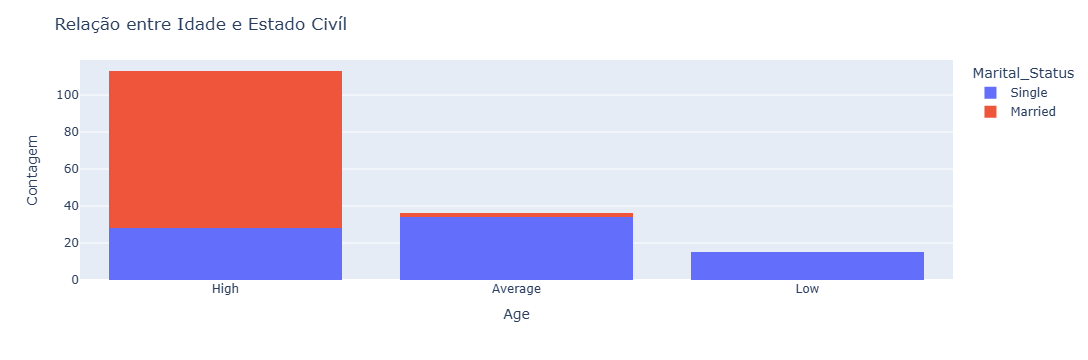

In [51]:
#Age e Marital_Status, com porcentagem (categ. x numer)
fig = px.histogram(df, x='Credit_Score', color='Marital_Status', barmode='stack')

# Layout
fig.update_layout(title='Relação entre Idade e Estado Civíl',
                  xaxis_title='Age',
                  yaxis_title='Contagem',
                  legend_title='Marital_Status')
fig.show()

In [ ]:
#Pessoas casadas são as que recebem Credit Score.

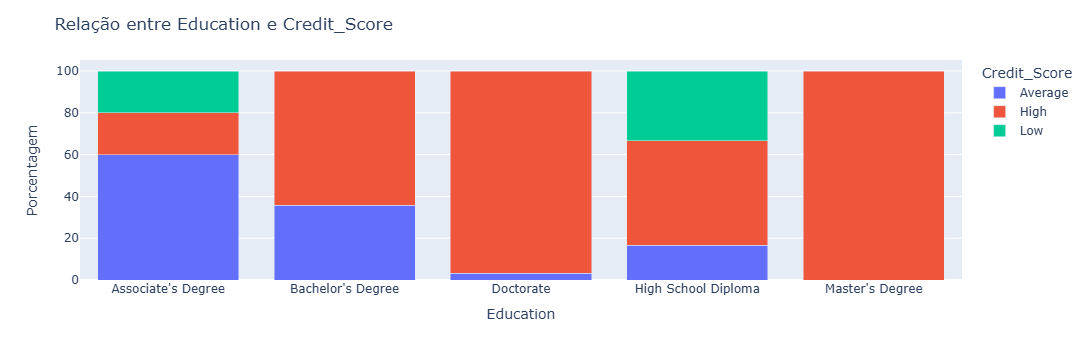

In [55]:
# Calcular a porcentagem de cada categoria
df_grouped = df.groupby(['Education', 'Credit_Score']).size().reset_index(name='count')
total_por_churn = df_grouped.groupby('Education')['count'].transform('sum')
df_grouped['percent'] = (df_grouped['count'] / total_por_churn) * 100

# Cria gráfico de barras empilhadas
fig = px.bar(df_grouped, x='Education', y='percent', color='Credit_Score', barmode='stack',
             labels={'Education': 'Education', 'percent': 'Porcentagem', 'Credit_Score': 'Credit_Score'})

fig.update_layout(title='Relação entre Education e Credit_Score',
                  yaxis_title='Porcentagem',
                  legend_title='Credit_Score')
fig.show()

In [ ]:
#A disponibilidade de crédito mais alta foi para aqueles que apresentaram Mestrado (Master's Degree) com 100%, Doutorate(Doctorate') com 96%, e 
#Bacharelado(Bachelor's Degree) com 64%, logo a disponibilização de um crédito mais alto é influenciada pelo grau de escolaridade e educação.

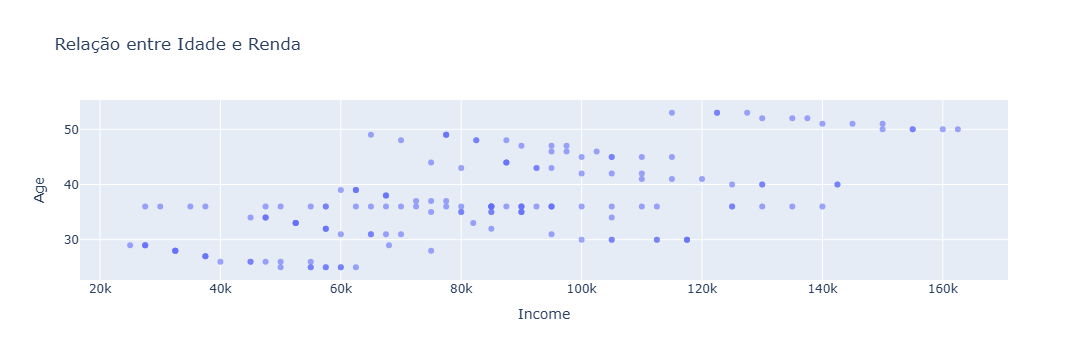

In [66]:
#Analise bivariada entre Idade e Renda (numéricas)
fig = px.scatter(df, x="Income", y="Age", title="Relação entre Idade e Renda",
                 labels={"idade": "Idade", "renda": "Renda"}, opacity=0.6,
)

fig.show()

In [ ]:
#As variáveis Income(Salário), parece estar relacionada com Age(Idade).

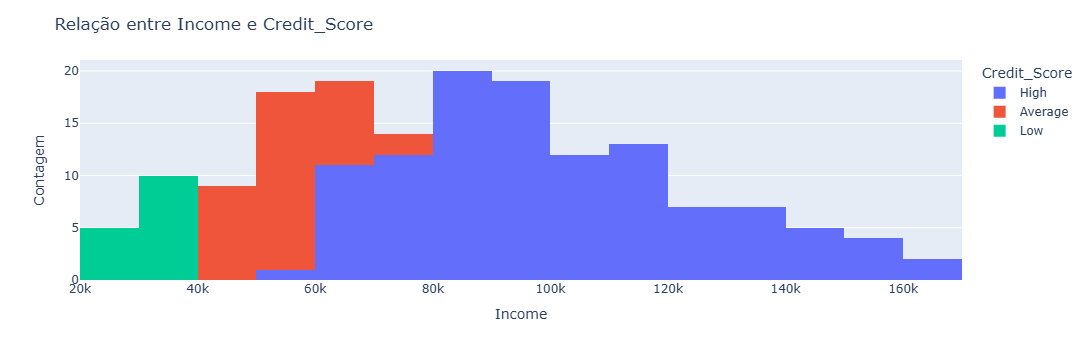

In [67]:
fig = px.histogram(df, x='Income', color='Credit_Score', barmode='stack')

# Layout
fig.update_layout(title='Relação entre Income e Credit_Score',
                  xaxis_title='Income',
                  yaxis_title='Contagem',
                  legend_title='Credit_Score')
fig.show()

In [ ]:
#Quanto maior o salário da pessoas mais score de crédito ela tem, portanto essas duas variáveis estão interligadas. 

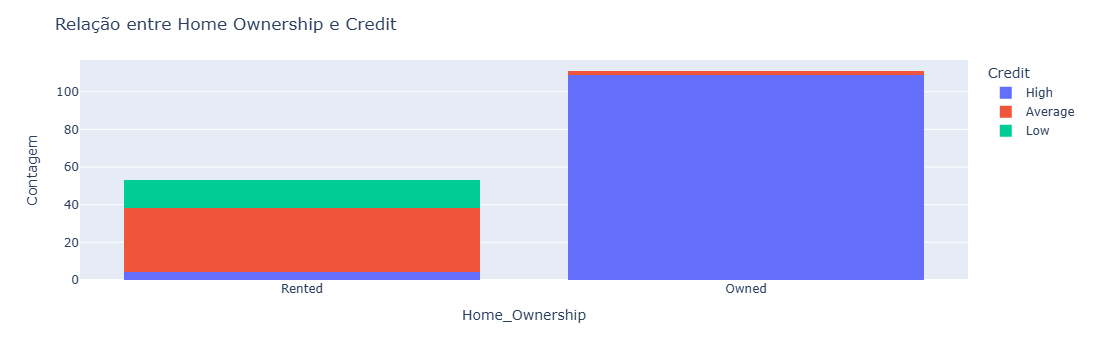

In [68]:
#Relação entre variáveis Home_Ownership e Credit_Score (categoricas)
fig = px.histogram(df, x='Home_Ownership', color='Credit_Score', barmode='stack')
fig.update_layout(title='Relação entre Home Ownership e Credit',
                  xaxis_title='Home_Ownership',
                  yaxis_title='Contagem',
                  legend_title='Credit')
fig.show()

In [ ]:
#Cliente com casa própria são os que mais recebem o score alto de crédito, com quase 100% para 'high'.

**E) Que outras perguntas te parecem fazer sentido explorarmos a resposta para conhecermos mais nossa base de dados e o comportamento dos clientes?**

 Elabore mais 3 perguntas e responda utilizando gráficos + insights.
 

1. O gênero influencia o nível de crédito disponibilizado?
2. Pessoas com mais filhos recebem mais crédito?
3. A quantidade de filhos está relacionada com o nível de educação?

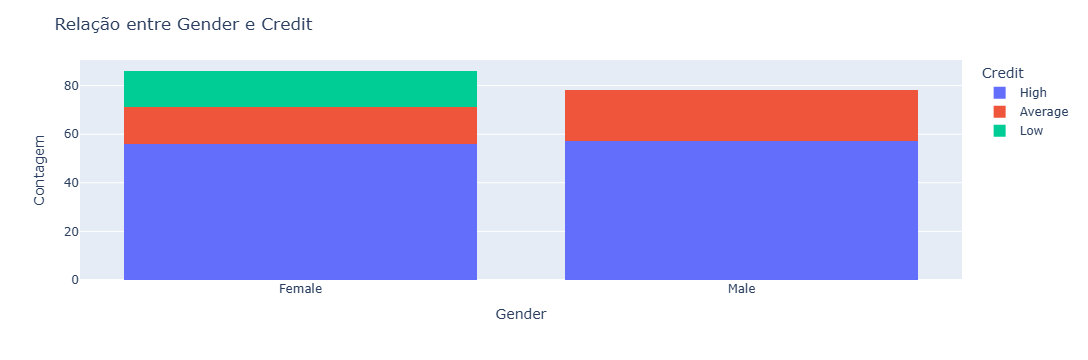

In [24]:
#Análise de gênero e crédito (categoricas).
fig = px.histogram(df, x='Gender', color='Credit_Score', barmode='stack')
fig.update_layout(title='Relação entre Gender e Credit',
                  xaxis_title='Gender',
                  yaxis_title='Contagem',
                  legend_title='Credit')
fig.show()

In [ ]:
#As variáveis parecem estar bem equilibradas, com excessão das mulheres receberem valores baixos para crédito e os homens não.

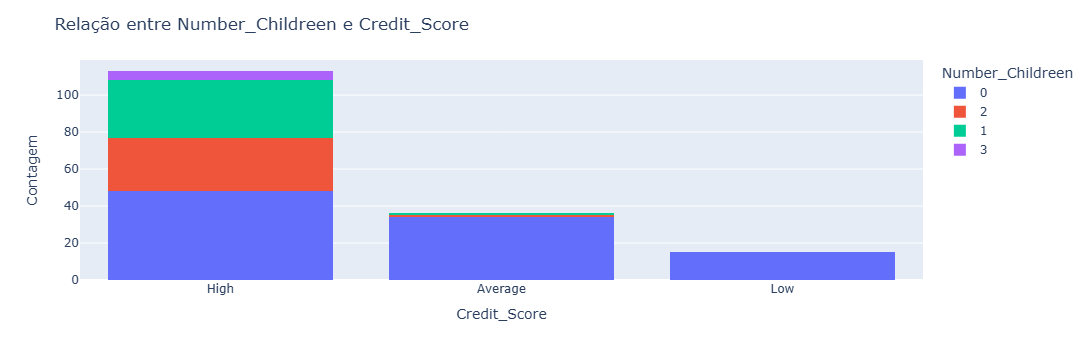

In [27]:
#Análise de gênero e crédito (categ. x numer.).

fig = px.histogram(df, x='Credit_Score', color='Number_Childreen', barmode='stack')

# Layout
fig.update_layout(title='Relação entre Number_Childreen e Credit_Score',
                  xaxis_title='Credit_Score',
                  yaxis_title='Contagem',
                  legend_title='Number_Childreen')
fig.show()

In [ ]:
#A variável 'high' é a que mais se distribui para as pessoas que possuem desde nenhum filho até 3. 

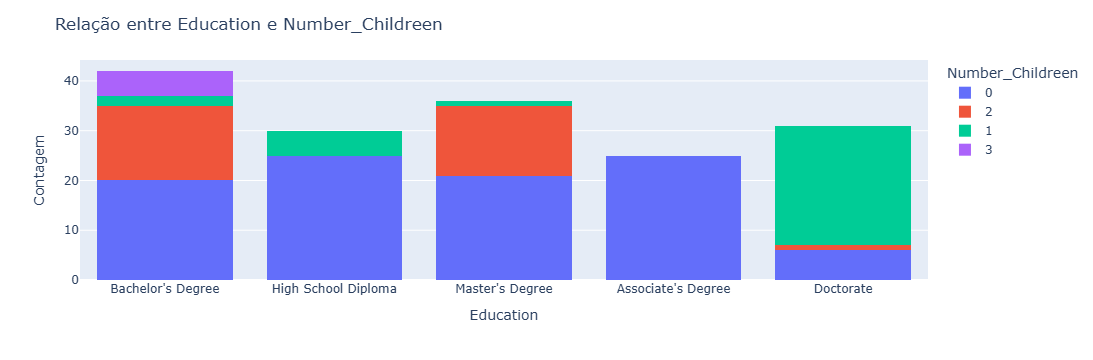

In [28]:
#Análise para filho x educação (categ. x numer)
fig = px.histogram(df, x='Education', color='Number_Childreen', barmode='stack')

# Layout
fig.update_layout(title='Relação entre Education e Number_Childreen',
                  xaxis_title='Education',
                  yaxis_title='Contagem',
                  legend_title='Number_Childreen')
fig.show()

In [ ]:
#Pessoas com educação maior tendem a ter nenhum filho ou ao menos 1.

# Etapa 3: Relize os passos que vimos no módulo 17, de Correlação, Balanceamento, atributos categóricos e divisão base treino e teste.

**A) Vamos começar pela análise de correlação, plote da forma que achar melhor a análise de correlação, seja pela tabela ou pelo gráfico da matriz.**

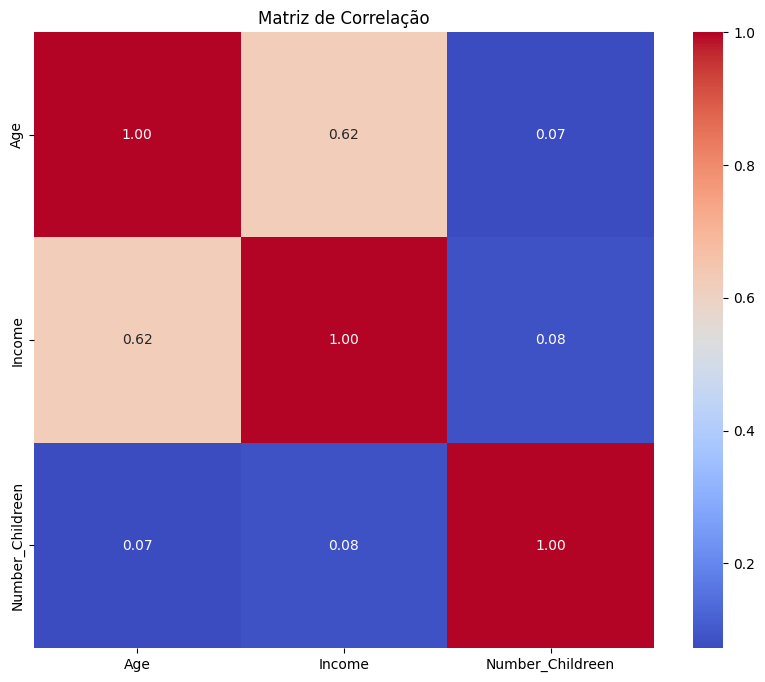

In [31]:
#Gráfico de correlação das variáveis numéricas.
corr_matriz = df.select_dtypes(include=['number']).corr()

# Plotar o mapa de calor da matriz de correlação
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matriz, annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size": 10})
plt.title('Matriz de Correlação')
plt.show()

**B) Você encontrou variáveis que tem uma média ou alta correlação? Se sim, quais? Te parece fazer sentido essas variáveis terem alta correlação? Justifique.**

In [ ]:
#A maior correlação no gráfico é entre 'Age' e 'Income', e a correlação mais baixa está entre 'Age' e 'Number_Childreen'.
#Age e Income estarem com alta relação faz sentido, pois a renda pode aumentar a medida que se envelhece, pois se procura condições melhores de vida. 

**C) Temos muitos atributos categóricos nessa base, não? Vamos realizar a o tratamento desses atributos utilizando Label Encoder ou one hot. Após, exclua as colunas categóricas.**

In [13]:
df

,Age,Gender,Income,Education,Marital_Status,Number_Childreen,Home_Ownership,Credit_Score
0,25,Female,50000.0,Bachelor's Degree,Single,0,Rented,High
1,30,Male,100000.0,Master's Degree,Married,2,Owned,High
2,35,Female,75000.0,Doctorate,Married,1,Owned,High
3,40,Male,125000.0,High School Diploma,Single,0,Owned,High
4,45,Female,100000.0,Bachelor's Degree,Married,3,Owned,High
...,...,...,...,...,...,...,...,...
159,29,Female,27500.0,High School Diploma,Single,0,Rented,Low
160,34,Male,47500.0,Associate's Degree,Single,0,Rented,Average
161,39,Female,62500.0,Bachelor's Degree,Married,2,Owned,High
162,44,Male,87500.0,Master's Degree,Single,0,Owned,High


In [25]:
from sklearn.preprocessing import LabelEncoder

#Criando instância de Label Encoder
label_encoder = LabelEncoder()

#Aplicando Label na coluna 'Gender'(gênero).
df['Gender_encoded'] = label_encoder.fit_transform(df['Gender'])

df

,Age,Gender,Income,Marital_Status,Number_Childreen,Home_Ownership,Credit_Score,Gender_encoded,Marital_Status_encoded,Home_Ownership_encoded,Credit_Score_encoded,Education_Bachelor's Degree,Education_Doctorate,Education_High School Diploma,Education_Master's Degree
0,25,Female,50000.0,Single,0,Rented,High,0,1,1,1,True,False,False,False
1,30,Male,100000.0,Married,2,Owned,High,1,0,0,1,False,False,False,True
2,35,Female,75000.0,Married,1,Owned,High,0,0,0,1,False,True,False,False
3,40,Male,125000.0,Single,0,Owned,High,1,1,0,1,False,False,True,False
4,45,Female,100000.0,Married,3,Owned,High,0,0,0,1,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159,29,Female,27500.0,Single,0,Rented,Low,0,1,1,2,False,False,True,False
160,34,Male,47500.0,Single,0,Rented,Average,1,1,1,0,False,False,False,False
161,39,Female,62500.0,Married,2,Owned,High,0,0,0,1,True,False,False,False
162,44,Male,87500.0,Single,0,Owned,High,1,1,0,1,False,False,False,True


In [20]:
#Criando instância de Label Encoder
label_encoder = LabelEncoder()

#Aplicando Label na coluna 'Gender'(gênero).
df['Marital_Status_encoded'] = label_encoder.fit_transform(df['Marital_Status'])

In [21]:
#Criando instância de Label Encoder
label_encoder = LabelEncoder()

#Aplicando Label na coluna 'Home_Ownership'(Imóvel)
df['Home_Ownership_encoded'] = label_encoder.fit_transform(df['Home_Ownership'])

In [23]:
#Criando instância de Label Encoder
label_encoder = LabelEncoder()

#Aplicando Label na coluna 'Credit_Score'(Crédito).
df['Credit_Score_encoded'] = label_encoder.fit_transform(df['Credit_Score'])

#High=1; Low=2; Average=0.

In [ ]:
df = pd.get_dummies(df, columns=['Education'], prefix='Education', drop_first=True)

In [29]:
df = pd.get_dummies(df, columns=['Number_Childreen'], prefix='Number_Childreen', drop_first=True)
df

,Age,Gender,Income,Marital_Status,Home_Ownership,Credit_Score,Gender_encoded,Marital_Status_encoded,Home_Ownership_encoded,Credit_Score_encoded,Education_Bachelor's Degree,Education_Doctorate,Education_High School Diploma,Education_Master's Degree,Number_Childreen_1,Number_Childreen_2,Number_Childreen_3
0,25,Female,50000.0,Single,Rented,High,0,1,1,1,True,False,False,False,False,False,False
1,30,Male,100000.0,Married,Owned,High,1,0,0,1,False,False,False,True,False,True,False
2,35,Female,75000.0,Married,Owned,High,0,0,0,1,False,True,False,False,True,False,False
3,40,Male,125000.0,Single,Owned,High,1,1,0,1,False,False,True,False,False,False,False
4,45,Female,100000.0,Married,Owned,High,0,0,0,1,True,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159,29,Female,27500.0,Single,Rented,Low,0,1,1,2,False,False,True,False,False,False,False
160,34,Male,47500.0,Single,Rented,Average,1,1,1,0,False,False,False,False,False,False,False
161,39,Female,62500.0,Married,Owned,High,0,0,0,1,True,False,False,False,False,True,False
162,44,Male,87500.0,Single,Owned,High,1,1,0,1,False,False,False,True,False,False,False


In [31]:
# Dropar as colunas categóricas
df = df.drop(['Gender'], axis=1)

In [32]:
df = df.drop(['Marital_Status'], axis=1)

In [33]:
df = df.drop(['Home_Ownership'], axis=1)

In [34]:
df = df.drop(['Credit_Score'], axis=1)
df

,Age,Income,Gender_encoded,Marital_Status_encoded,Home_Ownership_encoded,Credit_Score_encoded,Education_Bachelor's Degree,Education_Doctorate,Education_High School Diploma,Education_Master's Degree,Number_Childreen_1,Number_Childreen_2,Number_Childreen_3
0,25,50000.0,0,1,1,1,True,False,False,False,False,False,False
1,30,100000.0,1,0,0,1,False,False,False,True,False,True,False
2,35,75000.0,0,0,0,1,False,True,False,False,True,False,False
3,40,125000.0,1,1,0,1,False,False,True,False,False,False,False
4,45,100000.0,0,0,0,1,True,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
159,29,27500.0,0,1,1,2,False,False,True,False,False,False,False
160,34,47500.0,1,1,1,0,False,False,False,False,False,False,False
161,39,62500.0,0,0,0,1,True,False,False,False,False,True,False
162,44,87500.0,1,1,0,1,False,False,False,True,False,False,False


**D) Vamos plotar novamente a correlação, agora observando com as variáveis categóricas. Identifique se temos novas variáveis com forte correlação.**

In [35]:
#Correlação em tabela
df.select_dtypes(include=['number']).corr()

,Age,Income,Gender_encoded,Marital_Status_encoded,Home_Ownership_encoded,Credit_Score_encoded
Age,1.000000,0.621492,0.204661,-0.449115,-0.628042,0.218494
Income,0.621492,1.000000,0.495738,-0.471004,-0.704928,0.083698
Gender_encoded,0.204661,0.495738,1.000000,0.278362,-0.031519,-0.247729
Marital_Status_encoded,-0.449115,-0.471004,0.278362,1.000000,0.708374,-0.205756
Home_Ownership_encoded,-0.628042,-0.704928,-0.031519,0.708374,1.000000,-0.293384
Credit_Score_encoded,0.218494,0.083698,-0.247729,-0.205756,-0.293384,1.000000


In [ ]:
#'Home_Ownership_encoded' tem uma boa relação positiva com 'Marital_Status_encoded' (inclusive é a mais alta relação dentro da tabela)
#A segunda nova observada (depois de Income e Age) mais alta é de Gender_encoded e Income, mas não é tão alta, mas se comparada as demais é válida.

**F) Faça a separação da base em treino e teste e verifique utilizando shape:**

In [38]:
# Separar os dados em features (X) e o alvo (y)
X = df.drop('Credit_Score_encoded', axis=1)  # Considerando que 'Credit_Score' é a coluna a ser predita
y = df['Credit_Score_encoded']

In [36]:
from sklearn.model_selection import train_test_split

In [39]:
# Separar os dados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [40]:
X_train

,Age,Income,Gender_encoded,Marital_Status_encoded,Home_Ownership_encoded,Education_Bachelor's Degree,Education_Doctorate,Education_High School Diploma,Education_Master's Degree,Number_Childreen_1,Number_Childreen_2,Number_Childreen_3
141,26,45000.0,0,1,1,False,False,False,False,False,False,False
117,29,27500.0,0,1,1,False,False,True,False,False,False,False
93,25,62500.0,0,1,1,True,False,False,False,False,False,False
133,29,68000.0,0,0,0,False,True,False,False,False,True,False
36,31,65000.0,1,1,1,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
71,46,97500.0,0,0,0,False,False,True,False,True,False,False
106,32,57500.0,1,1,1,False,False,False,False,False,False,False
14,36,70000.0,0,0,0,True,False,False,False,False,True,False
92,36,85000.0,0,0,0,False,True,False,False,True,False,False


In [ ]:
X_test

In [43]:
y_train

141    0
117    2
93     0
133    0
36     0
      ..
71     1
106    0
14     1
92     1
102    1
Name: Credit_Score_encoded, Length: 123, dtype: int64

In [ ]:
y_test

In [45]:
print("Tamanho de X_train:", X_train.shape)

Tamanho de X_train: (123, 12)


In [46]:
print("Tamanho de X_train:", X_test.shape)

Tamanho de X_train: (41, 12)


In [47]:
print("Tamanho de X_train:", y_train.shape)

Tamanho de X_train: (123,)


In [48]:
print("Tamanho de X_train:", y_test.shape)

Tamanho de X_train: (41,)


**G) É hora de verificar se nossa coluna de Score de crédito está balanceada, verifique através de um gráfico e traga sua opinião acerca do balanceamento.**

<Axes: xlabel='Credit_Score_encoded'>

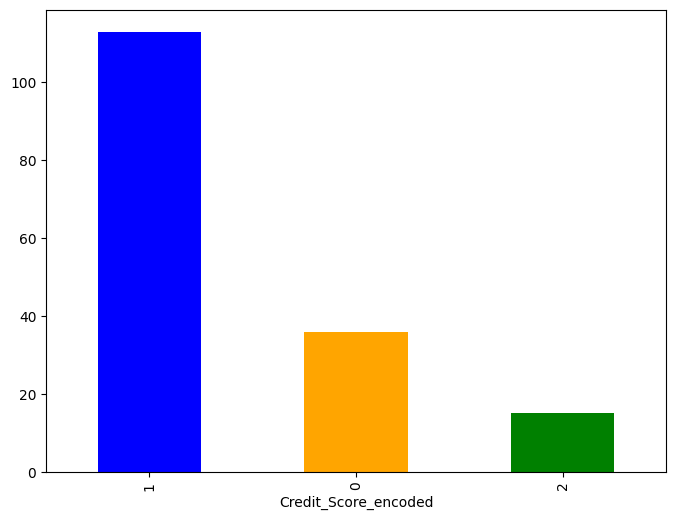

In [54]:
#Verificando balanceamento do crédito.
credit_counts = df['Credit_Score_encoded'].value_counts()
plt.figure(figsize=(8, 6))
credit_counts.plot(kind='bar', color=['blue', 'orange', 'green'])

In [55]:
# Calcular e imprimir as porcentagens dos valores na coluna 'churn'
print((df['Credit_Score_encoded'].value_counts(normalize=True) * 100))

Credit_Score_encoded
1    68.902439
0    21.951220
2     9.146341
Name: proportion, dtype: float64


In [ ]:
#Pelo observado a cima: High=1; Low=2; Avarege=0.
#O conjunto está bem desbalanceado, com maior presença de 'High=1'. 

**H) Vamos realizar o balancecamento dos dados da coluna de credit score.**
Se lembre que realizazmos apenas para a base de treino.

In [61]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

#Aplicar SMOTE aos dados de treinamento (X_train, y_train)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

#Verificar a ditribuição das classes após o balanceamento
print("Distribuição de classes após o balanceamento")
print(y_train_balanced.value_counts())

Distribuição de classes após o balanceamento
Credit_Score_encoded
0    84
2    84
1    84
Name: count, dtype: int64


In [62]:
train_balance = y_train_balanced.value_counts()
print("Balanceamento em y_train:")
print(train_balance)

Balanceamento em y_train:
Credit_Score_encoded
0    84
2    84
1    84
Name: count, dtype: int64


In [63]:
y_train_balanced.to_csv('y_train_balanced.csv', index=False)

In [64]:
X_train_balanced.to_csv('X_train_balanced.csv', index=False)

In [65]:
y_test.to_csv('y_test.csv', index=False)

In [66]:
X_test.to_csv('X_test.csv', index=False)